In [ ]:
"""
Author    : Mohammad Norizadeh Cherloo
Project   : Handwritten Digit Classification
Algorithm : Multi-Layer Perceptron (MLP) – PyTorch
"""

import pandas as pd
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
import numpy as np
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [37]:
ds= load_digits()
X = ds.data
y = ds.target

In [38]:
Xtrian, Xtest, ytrain, ytest = train_test_split(X, y, 
                                                test_size=0.2, 
                                                random_state=42)

In [39]:
class DigitsDataset(Dataset):
    def __init__(self, data, targets):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.long)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        x=  self.data[idx]
        y=  self.targets[idx]
        x= x.view(1, 64) 
        return x, y

In [40]:
train_dataset = DigitsDataset(Xtrian, ytrain)
test_dataset = DigitsDataset(Xtest, ytest)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,drop_last=True)

In [41]:
class MLP_Classifier(nn.Module):
    def __init__(self,
                 input_size=64,
                 hidden_size1=128, 
                 hidden_size2=128, 
                 num_classes=10):
        
        super(MLP_Classifier, self).__init__()
        

        self.fc1= nn.Linear(in_features=input_size,
                           out_features=hidden_size1)
        self.bn1= nn.BatchNorm1d(num_features=hidden_size1)
        
        self.fc2= nn.Linear(in_features=hidden_size1,
                                   out_features=hidden_size2)
        self.bn2= nn.BatchNorm1d(num_features=hidden_size2)
        
        self.fc3= nn.Linear(in_features=hidden_size1,
                                   out_features=num_classes)
        self.relu= nn.ReLU()
        
    def forward(self, x):
        
        out= self.fc1(x)
        out= self.bn1(out)
        out= self.relu(out)
        
        out= self.fc2(out)
        out= self.bn2(out)
        out= self.relu(out)
                
        out= self.fc3(out)
        
        return out

In [42]:
x,y=train_dataset[0]
num_features= x.shape[1]
criterion = nn.CrossEntropyLoss()
model = MLP_Classifier(input_size=num_features, 
                        hidden_size1=128, 
                        hidden_size2=128, 
                        num_classes=10)

optimizer = optim.Adam(model.parameters(), 
                       lr=0.001)

In [43]:
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for inputs, labels in train_loader:
        inputs= inputs.squeeze()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

Epoch [1/20], Loss: 1.0790
Epoch [2/20], Loss: 0.3288
Epoch [3/20], Loss: 0.1826
Epoch [4/20], Loss: 0.1224
Epoch [5/20], Loss: 0.0941
Epoch [6/20], Loss: 0.0689
Epoch [7/20], Loss: 0.0478
Epoch [8/20], Loss: 0.0352
Epoch [9/20], Loss: 0.0266
Epoch [10/20], Loss: 0.0253
Epoch [11/20], Loss: 0.0222
Epoch [12/20], Loss: 0.0250
Epoch [13/20], Loss: 0.0133
Epoch [14/20], Loss: 0.0136
Epoch [15/20], Loss: 0.0110
Epoch [16/20], Loss: 0.0148
Epoch [17/20], Loss: 0.0091
Epoch [18/20], Loss: 0.0106
Epoch [19/20], Loss: 0.0061
Epoch [20/20], Loss: 0.0114


Test Accuracy: 98.58%


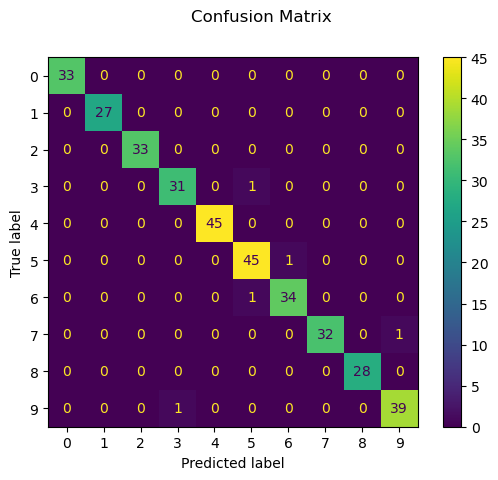

In [44]:
with torch.no_grad():
    model.eval()
    correct = 0
    total = 0
    ypred_list = []
    ytrue_list = []
    h0 = None
    for inputs, labels in test_loader:
        inputs= inputs.squeeze()
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        ypred_list.extend(predicted.cpu().numpy())
        ytrue_list.extend(labels.cpu().numpy())
    
accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')
# Confusion Matrix

cm = confusion_matrix(ytrue_list, ypred_list)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.figure_.suptitle("Confusion Matrix")
plt.show()
    